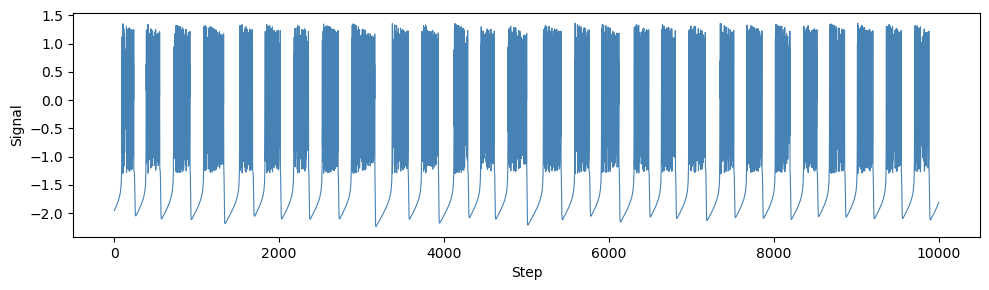

Total combinations to evaluate: 576
[20/576]  elapsed: 264s  current best NRMSE: 1.357581
[40/576]  elapsed: 621s  current best NRMSE: 1.357581
[60/576]  elapsed: 987s  current best NRMSE: 1.357581
[80/576]  elapsed: 1292s  current best NRMSE: 1.357581
[100/576]  elapsed: 1551s  current best NRMSE: 1.357581
[120/576]  elapsed: 1857s  current best NRMSE: 1.342835
[140/576]  elapsed: 2145s  current best NRMSE: 1.342835
[160/576]  elapsed: 2451s  current best NRMSE: 1.342835
[180/576]  elapsed: 2791s  current best NRMSE: 1.342835
[200/576]  elapsed: 3123s  current best NRMSE: 1.342835
[220/576]  elapsed: 3443s  current best NRMSE: 1.342835
[240/576]  elapsed: 3750s  current best NRMSE: 1.342835
[260/576]  elapsed: 4035s  current best NRMSE: 1.342835
[280/576]  elapsed: 4339s  current best NRMSE: 1.342835
[300/576]  elapsed: 4941s  current best NRMSE: 1.342835
[320/576]  elapsed: 5779s  current best NRMSE: 1.015504
[340/576]  elapsed: 6549s  current best NRMSE: 1.015504
[360/576]  elapsed:

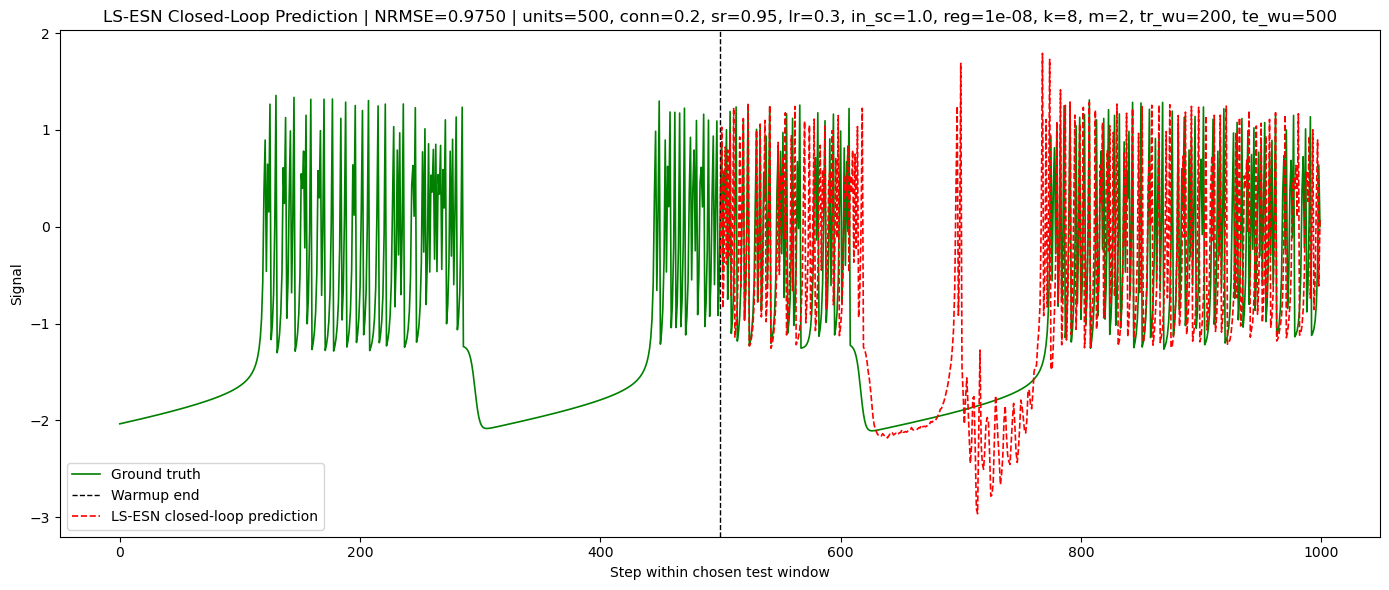

In [1]:
"""
Long-Short Term Echo State Network (LS-ESN) for Rulkov Map Closed-Loop Prediction.

Architecture (Zheng et al. 2020, IEEE Access):
  - Long-term reservoir: x_long(t) depends on x_long(t-k) via skip connection
  - Typical reservoir:   x_typ(t)  depends on x_typ(t-1), standard ESN
  - Short-term reservoir: x_short(t) computed by re-initializing x(t-m) from
    a standard normal distribution and iterating forward m steps (memory erasure)

  Concatenated state X(t) = [x_long; x_typ; x_short] in R^{3N} feeds a ridge
  readout trained in one shot on one-step-ahead targets.

Adaptations for closed-loop on the Rulkov map:
  - After training, we reset all three reservoirs, synchronize them on a warmup
    portion of the test series, then feed each prediction back as the next input.
  - The short-term reservoir's per-step random re-initialization is preserved
    verbatim from the paper (see note in docstring of ShortTermReservoir).
"""

import itertools
import time
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# SCALERS (match the interface implied by your previous code)
# ==========================================================
def fit_scaler(X, method="zscore"):
    X = np.asarray(X)
    if method == "none":
        return {"method": "none"}
    if method == "zscore":
        return {"method": "zscore", "mu": X.mean(axis=0), "sd": X.std(axis=0) + 1e-12}
    if method == "minmax01":
        return {"method": "minmax01", "lo": X.min(axis=0), "hi": X.max(axis=0)}
    if method == "minmax11":
        return {"method": "minmax11", "lo": X.min(axis=0), "hi": X.max(axis=0)}
    raise ValueError(method)


def transform_array(X, scaler):
    X = np.asarray(X)
    m = scaler["method"]
    if m == "none":
        return X.copy()
    if m == "zscore":
        return (X - scaler["mu"]) / scaler["sd"]
    if m == "minmax01":
        return (X - scaler["lo"]) / (scaler["hi"] - scaler["lo"] + 1e-12)
    if m == "minmax11":
        return 2.0 * (X - scaler["lo"]) / (scaler["hi"] - scaler["lo"] + 1e-12) - 1.0


def inverse_transform_array(X, scaler):
    X = np.asarray(X)
    m = scaler["method"]
    if m == "none":
        return X.copy()
    if m == "zscore":
        return X * scaler["sd"] + scaler["mu"]
    if m == "minmax01":
        return X * (scaler["hi"] - scaler["lo"]) + scaler["lo"]
    if m == "minmax11":
        return (X + 1.0) / 2.0 * (scaler["hi"] - scaler["lo"]) + scaler["lo"]


# ==========================================================
# RESERVOIR WEIGHT INITIALIZATION
# ==========================================================
def init_reservoir_weights(N, D, sr, input_scaling, connectivity, rng):
    """
    Following the paper:
      - W entries drawn uniformly in [-0.5, 0.5], sparsified, rescaled to sr.
      - Win entries drawn uniformly in [-IS, IS], dense.
      - bias uniform in [-0.5, 0.5].
    """
    # Recurrent weights: sparse, then spectral-radius scaled
    W = rng.uniform(-0.5, 0.5, size=(N, N))
    mask = rng.uniform(0.0, 1.0, size=(N, N)) < connectivity
    W = W * mask
    # Spectral radius scaling
    eigs = np.linalg.eigvals(W)
    rho = np.max(np.abs(eigs))
    if rho > 0:
        W = W * (sr / rho)

    # Input weights: dense
    Win = rng.uniform(-input_scaling, input_scaling, size=(N, D))

    # Bias
    bias = rng.uniform(-0.5, 0.5, size=(N,))

    return W, Win, bias


# ==========================================================
# LS-ESN
# ==========================================================
class LSESN:
    """
    Three reservoirs in parallel, with the same size N, each with its own
    frozen random (W, Win, bias). The readout is a ridge regression over the
    concatenated 3N-dimensional state.

    For the present work we share the scalar hyperparameters (sr, lr, IS, conn)
    across reservoirs. The paper tunes them per-reservoir (see their Table 1);
    that can be added by splitting the params into three sets.
    """

    def __init__(
        self,
        N=500,
        D=1,
        sr=0.95,
        lr=0.3,
        input_scaling=1.0,
        connectivity=0.1,
        k=4,        # skip step for long-term reservoir
        m=2,        # dependency scope for short-term reservoir
        ridge=1e-6,
        seed=42,
    ):
        self.N = N
        self.D = D
        self.sr = sr
        self.lr = lr
        self.input_scaling = input_scaling
        self.connectivity = connectivity
        self.k = int(k)
        self.m = int(m)
        self.ridge = ridge
        self.seed = seed

        rng = np.random.default_rng(seed)

        # Three independent reservoirs
        self.W_long, self.Win_long, self.b_long = init_reservoir_weights(
            N, D, sr, input_scaling, connectivity, rng
        )
        self.W_typ, self.Win_typ, self.b_typ = init_reservoir_weights(
            N, D, sr, input_scaling, connectivity, rng
        )
        self.W_short, self.Win_short, self.b_short = init_reservoir_weights(
            N, D, sr, input_scaling, connectivity, rng
        )

        # RNG reused for per-step sampling in the short-term reservoir
        self.rng_short = np.random.default_rng(seed + 1)

        self.Wout = None  # trained ridge readout, shape (D, 3N)

    # ---------- Per-step updates ----------
    @staticmethod
    def _step(x_prev, u, W, Win, bias, lr):
        """Leaky-integrator ESN step with tanh activation."""
        pre = Win @ u + W @ x_prev + bias
        return (1.0 - lr) * x_prev + lr * np.tanh(pre)

    def _long_state_sequence(self, U):
        """
        Long-term reservoir with skip step k.

        Paper's Eq. 4:
            x_long(t) = gamma * tanh(Win u(t) + W x_long(t-k) + b)
                        + (1 - gamma) * x_long(t-k)

        For t < k we don't yet have x_long(t-k); we bootstrap by using the
        typical one-step update on zero state until step k is reached.
        This matches the standard warmup-from-zero practice.
        """
        T = len(U)
        X = np.zeros((T, self.N))
        x = np.zeros(self.N)
        for t in range(T):
            if t < self.k:
                # Bootstrap with a standard one-step update so the reservoir
                # has meaningful state before we can reach back k steps.
                x = self._step(x, U[t], self.W_long, self.Win_long, self.b_long, self.lr)
                X[t] = x
            else:
                x_prev = X[t - self.k]
                x = self._step(x_prev, U[t], self.W_long, self.Win_long, self.b_long, self.lr)
                X[t] = x
        return X

    def _typical_state_sequence(self, U):
        T = len(U)
        X = np.zeros((T, self.N))
        x = np.zeros(self.N)
        for t in range(T):
            x = self._step(x, U[t], self.W_typ, self.Win_typ, self.b_typ, self.lr)
            X[t] = x
        return X

    def _short_state_sequence(self, U):
        """
        Short-term reservoir with dependency scope m.

        Paper's Eqs. 6-8: to produce x_short(t), re-initialize x(t-m) from a
        standard normal distribution, then iterate the standard update forward
        m times using inputs u(t-m+1), ..., u(t).

        NOTE: This re-initialization happens at EVERY t, so the short-term
        reservoir carries no long-range memory and produces a slightly
        stochastic feature at each step. In closed-loop rollout this adds
        noise at every step; if that destabilizes things, the natural fix
        is to freeze the random seed per step or drop this reservoir.
        """
        T = len(U)
        X = np.zeros((T, self.N))
        m = self.m
        for t in range(T):
            # Re-initialize m steps back
            x = self.rng_short.standard_normal(self.N)
            # Iterate forward m steps using inputs u(t-m+1) ... u(t)
            start = max(0, t - m + 1)
            for s in range(start, t + 1):
                x = self._step(x, U[s], self.W_short, self.Win_short, self.b_short, self.lr)
            X[t] = x
        return X

    # ---------- Concatenation ----------
    def _collect_states(self, U):
        X_long = self._long_state_sequence(U)
        X_typ = self._typical_state_sequence(U)
        X_short = self._short_state_sequence(U)
        return np.concatenate([X_long, X_typ, X_short], axis=1)  # (T, 3N)

    # ---------- Training ----------
    def fit(self, U, Y, warmup=100):
        """
        U: (T, D) inputs
        Y: (T, D) targets (one-step-ahead)
        warmup: number of initial steps to discard before solving ridge
        """
        U = np.asarray(U, dtype=float)
        Y = np.asarray(Y, dtype=float)
        X = self._collect_states(U)                    # (T, 3N)
        X_use = X[warmup:]                             # (T - warmup, 3N)
        Y_use = Y[warmup:]                             # (T - warmup, D)

        # Ridge regression: Wout = Y^T X (X^T X + lambda I)^-1
        XtX = X_use.T @ X_use
        reg = self.ridge * np.eye(XtX.shape[0])
        XtY = X_use.T @ Y_use
        self.Wout = np.linalg.solve(XtX + reg, XtY).T  # (D, 3N)

        # Cache the final state vectors to allow continuation
        self._last_long = self._long_state_sequence(U)
        self._last_typ = self._typical_state_sequence(U)

    # ---------- Closed-loop prediction ----------
    def closed_loop(self, U_warmup, n_steps):
        """
        Synchronize the three reservoirs on U_warmup (a chunk of the test
        series driven by ground-truth inputs), then run n_steps of autonomous
        rollout where each prediction becomes the next input.

        Returns predictions of shape (n_steps, D).
        """
        assert self.Wout is not None, "Call fit() first."

        # --- Synchronize long-term reservoir ---
        T_w = len(U_warmup)
        # We need to keep the full history of x_long because of the skip.
        x_long_hist = np.zeros((T_w, self.N))
        x = np.zeros(self.N)
        for t in range(T_w):
            if t < self.k:
                x = self._step(x, U_warmup[t], self.W_long, self.Win_long, self.b_long, self.lr)
            else:
                x = self._step(x_long_hist[t - self.k], U_warmup[t],
                               self.W_long, self.Win_long, self.b_long, self.lr)
            x_long_hist[t] = x

        # --- Synchronize typical reservoir ---
        x_typ = np.zeros(self.N)
        for t in range(T_w):
            x_typ = self._step(x_typ, U_warmup[t], self.W_typ, self.Win_typ, self.b_typ, self.lr)

        # --- Short-term reservoir needs the last m inputs from warmup ---
        u_buffer = list(U_warmup[-(self.m - 1):]) if self.m > 1 else []

        # --- Closed-loop rollout ---
        preds = np.zeros((n_steps, self.D))
        # Need rolling history for x_long's skip
        x_long_roll = list(x_long_hist[-self.k:])  # length k; most recent at end

        # Current input starts as the last ground-truth step (consistent with
        # your previous code's "current_input = X_test[warmup:warmup+1]" pattern,
        # but here we step the network one autonomous step at a time).
        u_t = U_warmup[-1].copy()

        for step in range(n_steps):
            # Long-term state update: uses x_long from k steps ago
            x_prev_long = x_long_roll[0]  # this is the state from k steps back
            x_long_new = self._step(x_prev_long, u_t,
                                    self.W_long, self.Win_long, self.b_long, self.lr)
            x_long_roll.append(x_long_new)
            x_long_roll.pop(0)

            # Typical
            x_typ = self._step(x_typ, u_t, self.W_typ, self.Win_typ, self.b_typ, self.lr)

            # Short-term: re-init, iterate m steps with the most recent m inputs
            x_s = self.rng_short.standard_normal(self.N)
            recent = u_buffer + [u_t]
            recent = recent[-self.m:]
            for u_past in recent:
                x_s = self._step(x_s, u_past, self.W_short, self.Win_short, self.b_short, self.lr)

            # Concatenate and read out
            state = np.concatenate([x_long_new, x_typ, x_s])
            y_hat = self.Wout @ state   # shape (D,)
            preds[step] = y_hat

            # Update input buffers for next iteration
            u_buffer.append(u_t)
            if len(u_buffer) > self.m:
                u_buffer.pop(0)
            u_t = y_hat.copy()

        return preds


# ==========================================================
# LOAD DATA
# ==========================================================
dataset = np.loadtxt('../../data/chaotic_data/rulkov_map.csv', delimiter=',')
dataset = dataset[:, 0]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset[:], color='steelblue', linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Signal')
plt.tight_layout()
plt.show()


# ==========================================================
# DATA PREPARATION
# ==========================================================
data = dataset.reshape(-1, 1)
X_raw = data[:-1]
Y_raw = data[1:]


# ==========================================================
# FIXED SETTINGS
# ==========================================================
train_len = 4000
test_start = 4000
test_len = 1000

seed = 42

X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]
X_test_raw = X_raw[test_start:test_start + test_len]
Y_test_raw = Y_raw[test_start:test_start + test_len]


# ==========================================================
# PARAMETER GRID
#
# Kept modest: the full 3-reservoir split from Table 1 of the paper would
# require 9 separate scalar hyperparameters. Here we share across reservoirs
# and only vary the LS-ESN-specific ones (k, m) plus core RC parameters.
# ==========================================================
param_grid = {
    "normalization":          ["zscore"],
    "train_warmup":           [200],
    "test_warmup":            [500],
    "units":                  [300, 500],        # per-reservoir size; total state is 3x
    "reservoir_connectivity": [0.1, 0.2],
    "sr":                     [0.9, 0.95, 1.0],
    "lr":                     [0.3, 0.5],
    "input_scaling":          [0.5, 1.0],
    "regression":             [1e-8, 1e-6],
    "k":                      [2, 4, 8],          # long-term skip
    "m":                      [2, 4],             # short-term scope
}

keys = list(param_grid.keys())
combos = list(itertools.product(*[param_grid[k] for k in keys]))
print(f"Total combinations to evaluate: {len(combos)}")


# ==========================================================
# EVALUATION FUNCTION
# ==========================================================
def evaluate_lsesn(
    normalization,
    train_warmup,
    test_warmup,
    units,
    reservoir_connectivity,
    sr,
    lr,
    input_scaling,
    regression,
    k,
    m,
    seed=42,
):
    try:
        if test_warmup >= test_len:
            return np.inf

        scaler = fit_scaler(X_train_raw, method=normalization)
        X_train = transform_array(X_train_raw, scaler)
        Y_train = transform_array(Y_train_raw, scaler)
        X_test = transform_array(X_test_raw, scaler)
        Y_test = transform_array(Y_test_raw, scaler)

        pred_len = test_len - test_warmup
        Y_true_scaled = Y_test[test_warmup:test_warmup + pred_len, 0]

        if train_warmup >= len(X_train):
            return np.inf

        model = LSESN(
            N=int(units),
            D=1,
            sr=sr,
            lr=lr,
            input_scaling=input_scaling,
            connectivity=reservoir_connectivity,
            k=k,
            m=m,
            ridge=regression,
            seed=seed,
        )

        model.fit(X_train, Y_train, warmup=train_warmup)

        preds = model.closed_loop(X_test[:test_warmup], n_steps=pred_len)
        Y_pred_scaled = preds[:, 0]

        if np.any(np.isnan(Y_pred_scaled)) or np.any(np.isinf(Y_pred_scaled)):
            return np.inf
        if np.max(np.abs(Y_pred_scaled)) > 1e6:
            return np.inf

        rmse = np.sqrt(np.mean((Y_true_scaled - Y_pred_scaled) ** 2))
        denom = np.std(Y_true_scaled)
        if denom == 0:
            return np.inf

        return rmse / denom

    except Exception as e:
        print(f"    ERROR: {e}")
        return np.inf


# ==========================================================
# RUN GRID SEARCH
# ==========================================================
results = []
best_nrmse = np.inf
best_params = None

t_start = time.time()

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    nrmse = evaluate_lsesn(**params, seed=seed)
    results.append({**params, "nrmse": nrmse})

    if nrmse < best_nrmse:
        best_nrmse = nrmse
        best_params = params.copy()

    if (i + 1) % 20 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t_start
        print(
            f"[{i+1}/{len(combos)}]  "
            f"elapsed: {elapsed:.0f}s  "
            f"current best NRMSE: {best_nrmse:.6f}"
        )

total_time = time.time() - t_start


# ==========================================================
# RESULTS
# ==========================================================
print("\n" + "=" * 80)
print("GRID SEARCH COMPLETE")
print(f"Train interval      : [0 : {train_len}]")
print(f"Test interval       : [{test_start} : {test_start + test_len}]")
print(f"Total time          : {total_time:.1f}s ({total_time/len(combos):.2f}s per trial)")
print(f"Best NRMSE          : {best_nrmse:.6f}")
print("Best parameters:")
for key, v in best_params.items():
    print(f"  {key:24s} = {v}")
print("=" * 80)

results_sorted = sorted(results, key=lambda r: r["nrmse"])

print("\nTop 10 configurations:")
print(
    f"{'Rank':>4}  {'units':>5}  {'conn':>5}  {'sr':>5}  {'lr':>4}  "
    f"{'in_sc':>6}  {'reg':>8}  {'k':>3}  {'m':>3}  {'NRMSE':>10}"
)
print("-" * 100)
for rank, r in enumerate(results_sorted[:10], 1):
    print(
        f"{rank:4d}  "
        f"{int(r['units']):5d}  "
        f"{r['reservoir_connectivity']:5.2f}  "
        f"{r['sr']:5.2f}  "
        f"{r['lr']:4.1f}  "
        f"{r['input_scaling']:6.2f}  "
        f"{r['regression']:8.1e}  "
        f"{r['k']:3d}  "
        f"{r['m']:3d}  "
        f"{r['nrmse']:10.6f}"
    )


# ==========================================================
# REBUILD BEST MODEL
# ==========================================================
best_scaler = fit_scaler(X_train_raw, method=best_params["normalization"])

X_train_best = transform_array(X_train_raw, best_scaler)
Y_train_best = transform_array(Y_train_raw, best_scaler)
X_test_best = transform_array(X_test_raw, best_scaler)
Y_test_best = transform_array(Y_test_raw, best_scaler)

best_pred_len = test_len - best_params["test_warmup"]

best_model = LSESN(
    N=int(best_params["units"]),
    D=1,
    sr=best_params["sr"],
    lr=best_params["lr"],
    input_scaling=best_params["input_scaling"],
    connectivity=best_params["reservoir_connectivity"],
    k=best_params["k"],
    m=best_params["m"],
    ridge=best_params["regression"],
    seed=seed,
)

best_model.fit(X_train_best, Y_train_best, warmup=best_params["train_warmup"])

preds_best_scaled = best_model.closed_loop(
    X_test_best[:best_params["test_warmup"]],
    n_steps=best_pred_len,
)

Y_pred_best = inverse_transform_array(preds_best_scaled, best_scaler).ravel()
Y_true_best = inverse_transform_array(
    Y_test_best[best_params["test_warmup"]:best_params["test_warmup"] + best_pred_len],
    best_scaler,
).ravel()

mse = np.mean((Y_true_best - Y_pred_best) ** 2)
rmse = np.sqrt(mse)
nrmse = rmse / np.std(Y_true_best)

print("\nFinal best-model metrics in original scale:")
print(f"MSE   : {mse:.10f}")
print(f"RMSE  : {rmse:.10f}")
print(f"NRMSE : {nrmse:.10f}")


# ==========================================================
# VISUALIZATION
# ==========================================================
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    np.arange(test_len),
    Y_test_raw[:, 0],
    c="green",
    label="Ground truth",
    linewidth=1.2,
)

ax.axvline(
    best_params["test_warmup"],
    linestyle="--",
    c="k",
    linewidth=1.0,
    label="Warmup end",
)

ax.plot(
    np.arange(best_params["test_warmup"], best_params["test_warmup"] + best_pred_len),
    Y_pred_best,
    linestyle="--",
    c="red",
    linewidth=1.2,
    label="LS-ESN closed-loop prediction",
)

ax.set_title(
    f"LS-ESN Closed-Loop Prediction | NRMSE={nrmse:.4f} | "
    f"units={int(best_params['units'])}, "
    f"conn={best_params['reservoir_connectivity']}, "
    f"sr={best_params['sr']}, "
    f"lr={best_params['lr']}, "
    f"in_sc={best_params['input_scaling']}, "
    f"reg={best_params['regression']:.0e}, "
    f"k={best_params['k']}, m={best_params['m']}, "
    f"tr_wu={best_params['train_warmup']}, "
    f"te_wu={best_params['test_warmup']}"
)
ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()
plt.tight_layout()
plt.show()